# Using Y-factor method to calculate active component noise

## Introducing Y-factor method
The Y-factor method is a widely used technique in RF engineering to measure the noise figure/noise temperature of active components such as amplifiers and mixers. The method involves measuring the output noise power of the device under test (DUT) when it is connected to two different known input noise sources, typically referred to as the "hot" and "cold" sources.

$$
Y = \frac{P_{hot}}{P_{cold}}
$$

The hot and cold sources are often implemented using noise diodes turned on and off, or by using matched loads at different temperatures (e.g., room temperature and liquid nitrogen temperature). 

Characterizing this noise temperature is crucial for understanding the sensitivity of RF systems, especially for under one kelvin experiments where noise should be minimized. 

The Y-factor method serves another purpose in our calibration system, we have calibrator sources (i.e. a noise diode and blackbody). The spectral temperature of these sources need to be measured so that they could be effectively used to validate the whole system performance. The Y-factor method can be used to infer their temperatures. 

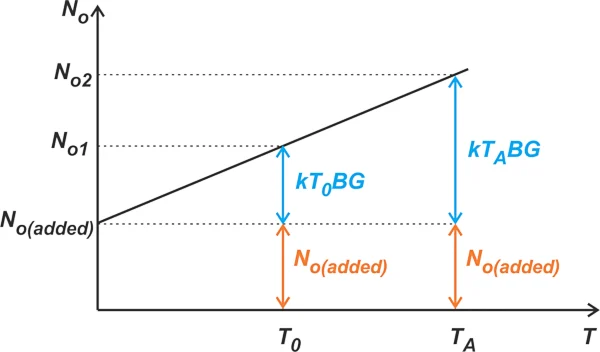

In [1]:
# import necessary modules
import os
from os.path import join as pjoin
import numpy as np
import skrf as rf
from matplotlib import pyplot as plt

pjoin = os.path.join
pbase = os.path.basename

We are going to use functionalities and classes in `highz_exp` pacakage to implement the Y-factor method. If you haven't installed this, please refer to the notebook [here](./load_spectrum.ipynb) for instructions.

In [2]:
# import relevant classes from highz_exp
from highz_exp.fit_temperature import Y_Factor_Thermometer
from highz_exp.s_params import S_Params
from highz_exp.spec_class import Spectrum
from highz_exp import plotter
from highz_exp.load_trc import TraceLoader

# set up data paths
data_path = pjoin(os.getcwd(), '../data/measurement_50ohm.trc')

This file contains four traces. Two traces belong to the hot/cold spectra of a 50.1 Ohm source, and the other two belong to those of a 49.3 Ohm source.

## Y-Factor Method without second-stage calibration
If our goal is not to measure the absolute noise temperature of the DUT, but rather to infer the temperature of some noise diodes, or the whole measurement system (including the SA), we can directly apply the Y-factor method without performing a second-stage calibration.

In [3]:
hot_1 = TraceLoader(data_path).load_trc_to_spec(1, name='50.1 Ohm - 300K')
hot_2 = TraceLoader(data_path).load_trc_to_spec(2, name='49.3 Ohm - 300K')
cold_1 = TraceLoader(data_path).load_trc_to_spec(3, name='50.1 Ohm - 77K')
cold_2 = TraceLoader(data_path).load_trc_to_spec(4, name='49.3 Ohm - 77K')

# uncomment to visualize 
# plotter.plot_spectra([hot_1, hot_2, cold_1, cold_2], title='Cable-Resistor Traces',
#       y_range=(-100, -80))

The measurements from SA are in dBm scale. We can convert them to Kelvin units by using $T=\frac{P}{k_B \Delta f}$, where $P$ is the noise power in Watts, $k_B$ is the Boltzmann constant, and $\Delta f$ is the resolution bandwidth of the SA. In this measurement, the resolution bandwidth is 1 MHz.

In [4]:
# we can use the `unit_convert` method in the `Spectrum` class to convert the spectra from dBm to Kelvin units. 
hot_1 = hot_1.unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
hot_2 = hot_2.unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
cold_1 = cold_1.unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)
cold_2 = cold_2.unit_convert(from_unit='dBm', to_unit='kelvin', channel_width=1e6)

A class called `Y_Factor_Thermometer` is implemented in the `highz_exp` package to perform the Y-factor calculation. We can use it to compute the system gain and system temperature.

In [5]:
# construct the Y-Factor thermometer object
LNA_thermo_1 = Y_Factor_Thermometer(frequency=hot_1.f, DUT_hot=hot_1.s, DUT_cold=cold_1.s,
    DUT_name='two amplifiers', T_hot=300, T_cold=77, RBW=1e6)

In [6]:
# uncomment to visualize system gain and system temperature
# LNA_thermo_1.plot_system_temperature(marker='o', ms=3, ls='', y_range=(0, 200))
# LNA_thermo_1.plot_gain(marker='o', ms=3, ls='')

In [7]:
# construct the second Y-Factor thermometer object
LNA_thermo_2 = Y_Factor_Thermometer(frequency=hot_2.f, DUT_hot=hot_2.s, DUT_cold=cold_2.s,
    DUT_name='two amplifiers', T_hot=300, T_cold=77, RBW=1e6)

/Users/yuntongzhou/Desktop/DevSpace/Highz-EXP/src/highz_exp/fit_temperature.py:110: RuntimeWarning: invalid value encountered in log10
  g = 10 * np.log10((DUT_hot - DUT_cold) / ((T_hot - T_cold)))


In [8]:
# uncomment to visualize system gain and system temperature
# LNA_thermo_2.plot_system_temperature(marker='o', ms=3, ls='', y_range=(0, 200))
# LNA_thermo_2.plot_gain(marker='o', ms=3, ls='')

We can plot the system gains with two slighty different 50 Ohm impedances together to look at the difference. Technically, the system gain should be slightly larger for the 49.3 Ohm source, because of voltage transfer/division factor.

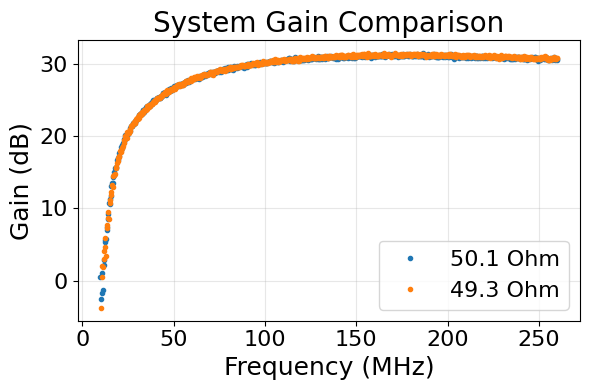

In [12]:
plotter.plot_gain(f_mhz=LNA_thermo_1.f/1e6, gain=[LNA_thermo_1.g, LNA_thermo_2.g], 
    label=['50.1 Ohm', '49.3 Ohm'], title='System Gain Comparison', xlabel='Frequency (MHz)', ylabel='Gain (dB)',
    marker='o', ms=3, ls='', figsize=(6, 4))

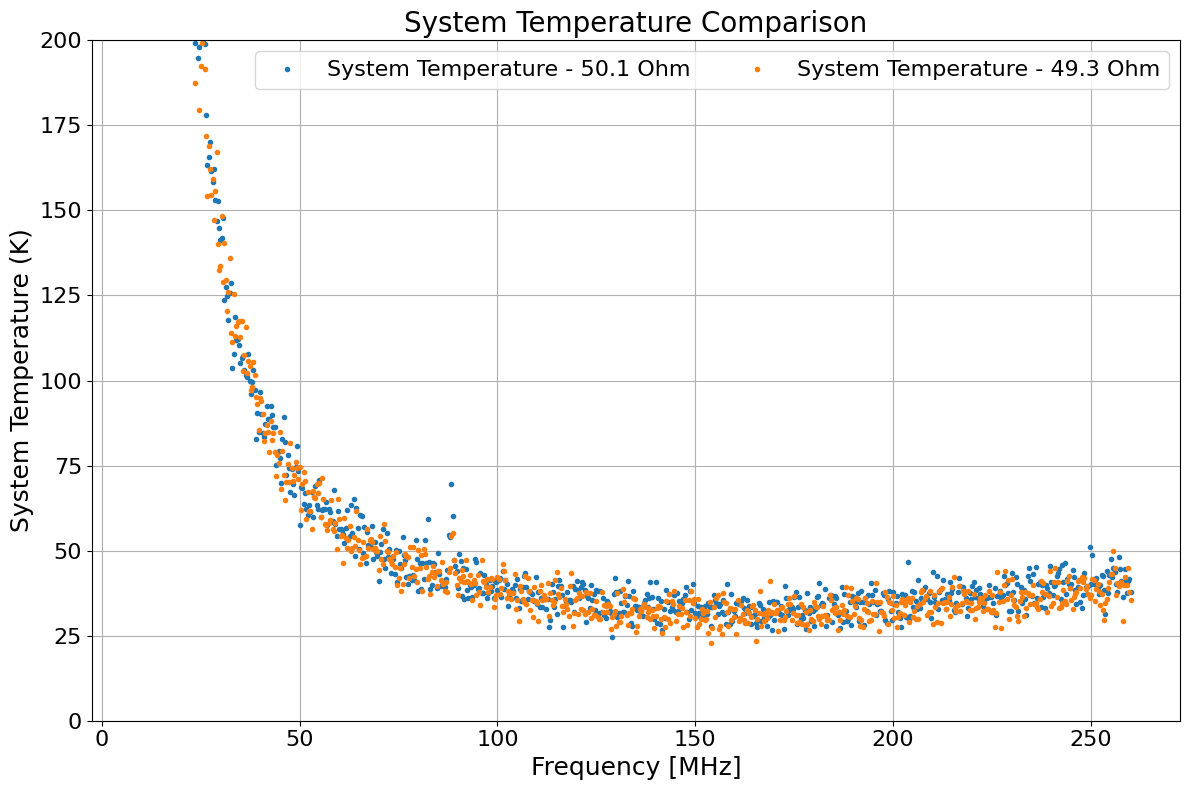

In [16]:
system_T_1 = Spectrum(LNA_thermo_1.f, LNA_thermo_1.T_sys, name='System Temperature - 50.1 Ohm')
system_T_2 = Spectrum(LNA_thermo_2.f, LNA_thermo_2.T_sys, name='System Temperature - 49.3 Ohm')

plotter.plot_spectra([system_T_1, system_T_2], title='System Temperature Comparison',
    y_range=(0, 200), ylabel='System Temperature (K)', marker='o', ms=3, ls='')

## Infer the temperature of another noise source
With the system gain, we can infer the temperature of another noise source with impedance of 50 Ohm. In this case, we can look at the 

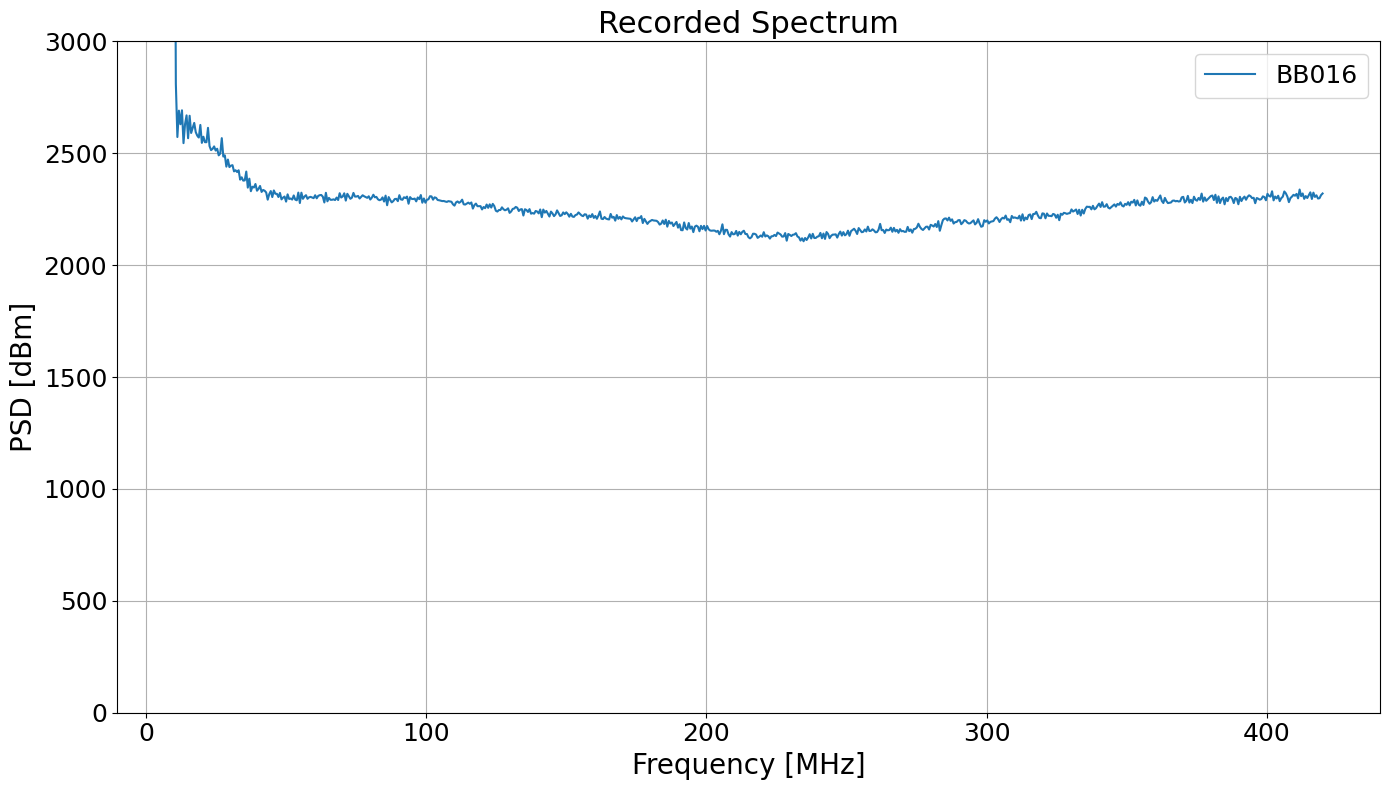

In [16]:
BB016_inferred = smoothed_thermo.infer_temp_with_known_gain(LNA01_BB016.unit_convert('dBm', 'kelvin', channel_width=1e6, inplace=False), s21_ntwk)
BB016_inferred.plot(y_range=(0, 3000))

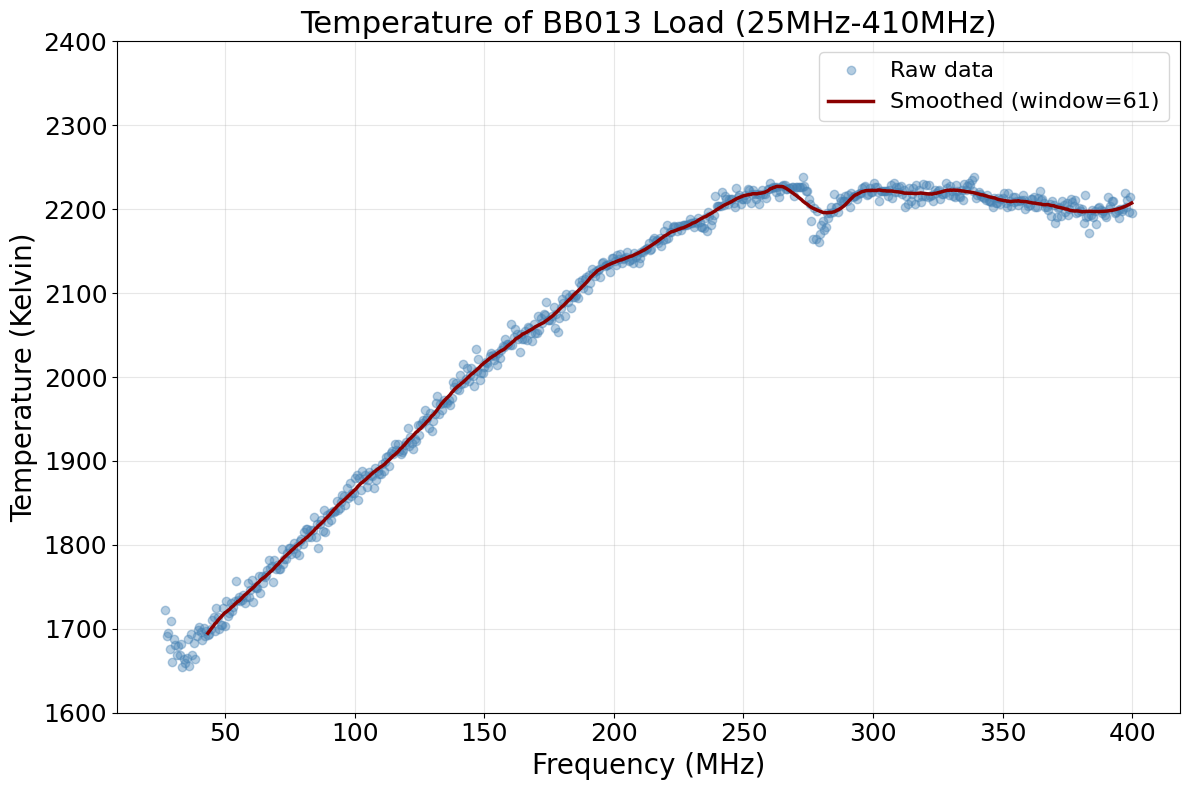

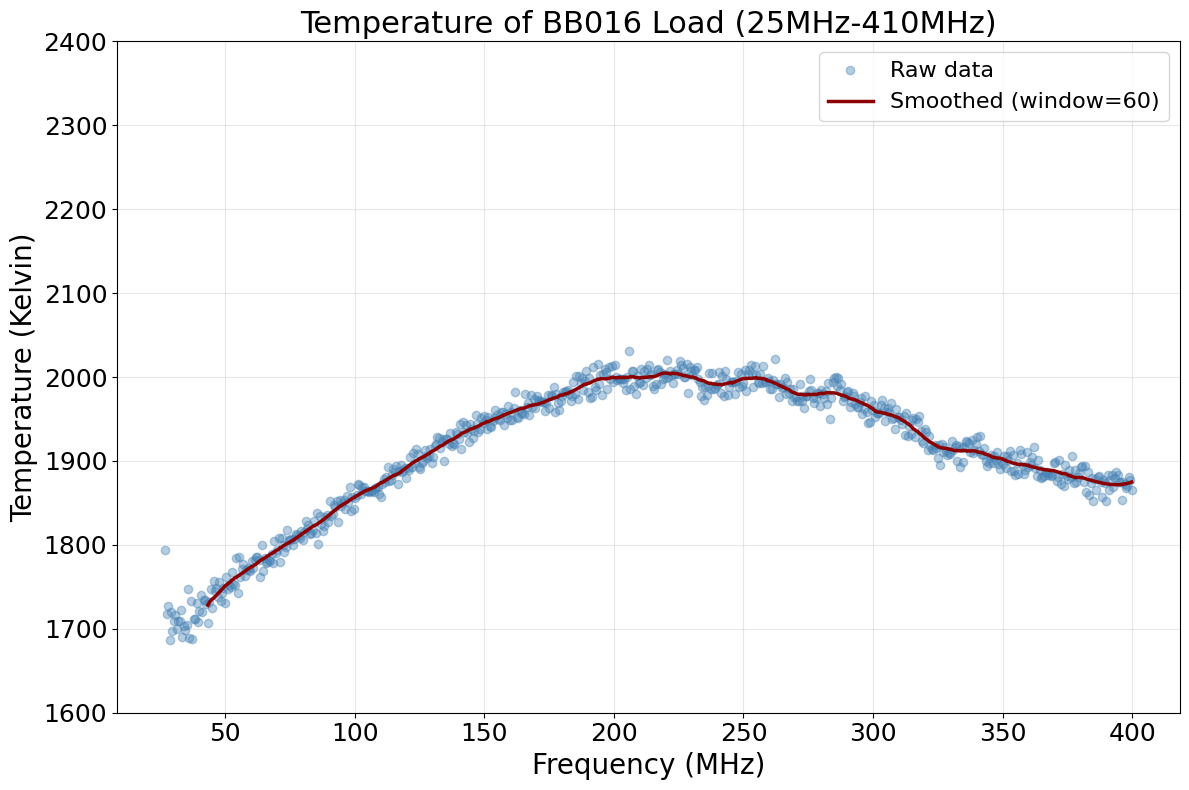

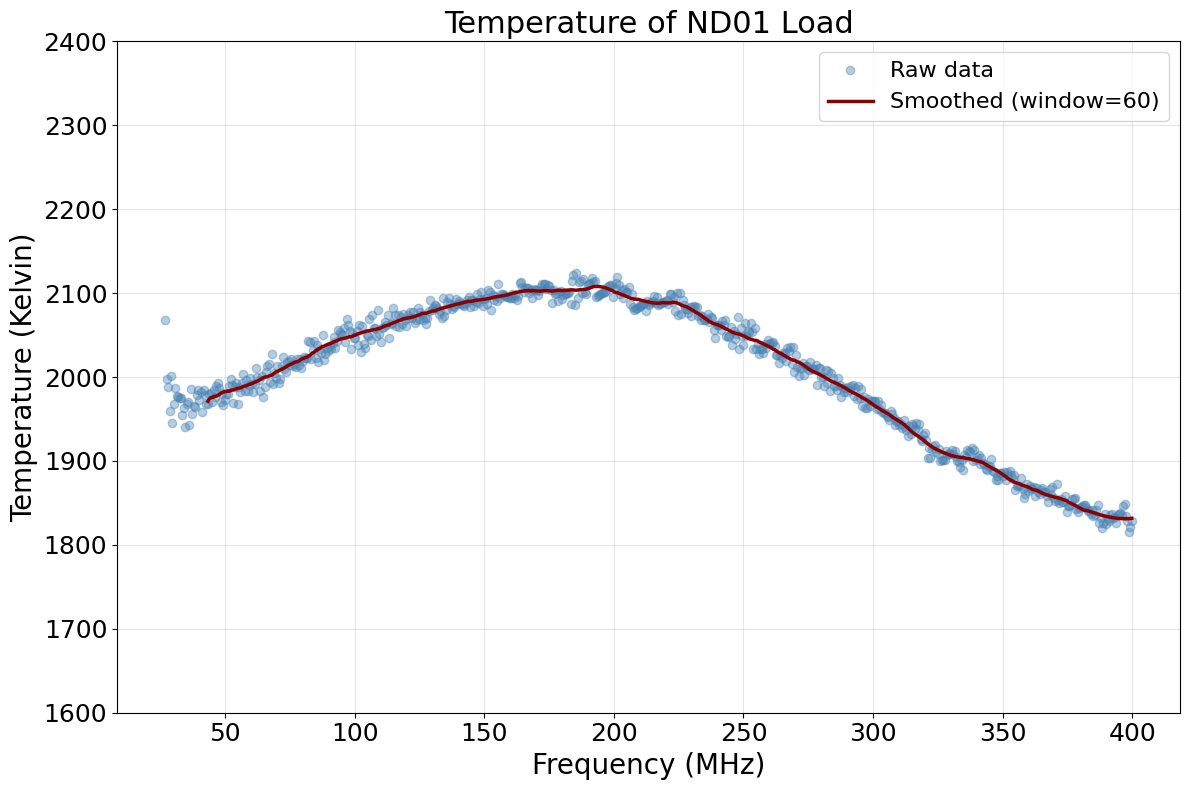

In [55]:
# LNA01_BB013.despike(threshold=5)
# LNA_thermo.smooth(inplace=True, smoothing_kwargs={"window":60})
BB013_inferred = smoothed_thermo.infer_temperature(BB013_Kelvin_despiked,  
                            ymax=2400, ymin=1600,
                            window_size=61,
                            title='Temperature of BB013 Load (25MHz-410MHz)',
                            save_path=pjoin(plot_path, 'BB013_Temperature_smoothed.png'))
                            # save_path=pjoin(plot_path, 'LNA01_Inferred_Temperature_BB013.png'))
BB016_inferred = smoothed_thermo.infer_temperature(LNA01_BB016.unit_convert('dBm', 'kelvin', 
                            channel_width=1e6, inplace=False), 
                            ymax=2400, ymin=1600,
                            window_size=60,
                            title='Temperature of BB016 Load (25MHz-410MHz)')
                            # save_path=pjoin(plot_path, 'BB016_Temperature.png'))
ND01_inferred = smoothed_thermo.infer_temperature(
    LNA01_ND01.unit_convert('dBm', 'kelvin', channel_width=1e6, inplace=False).despike(threshold=2), 
    ymax=2400, ymin=1600,
    window_size=60,
    title='Temperature of ND01 Load')
    # save_path=pjoin(plot_path, 'ND01_Temperature.png'))

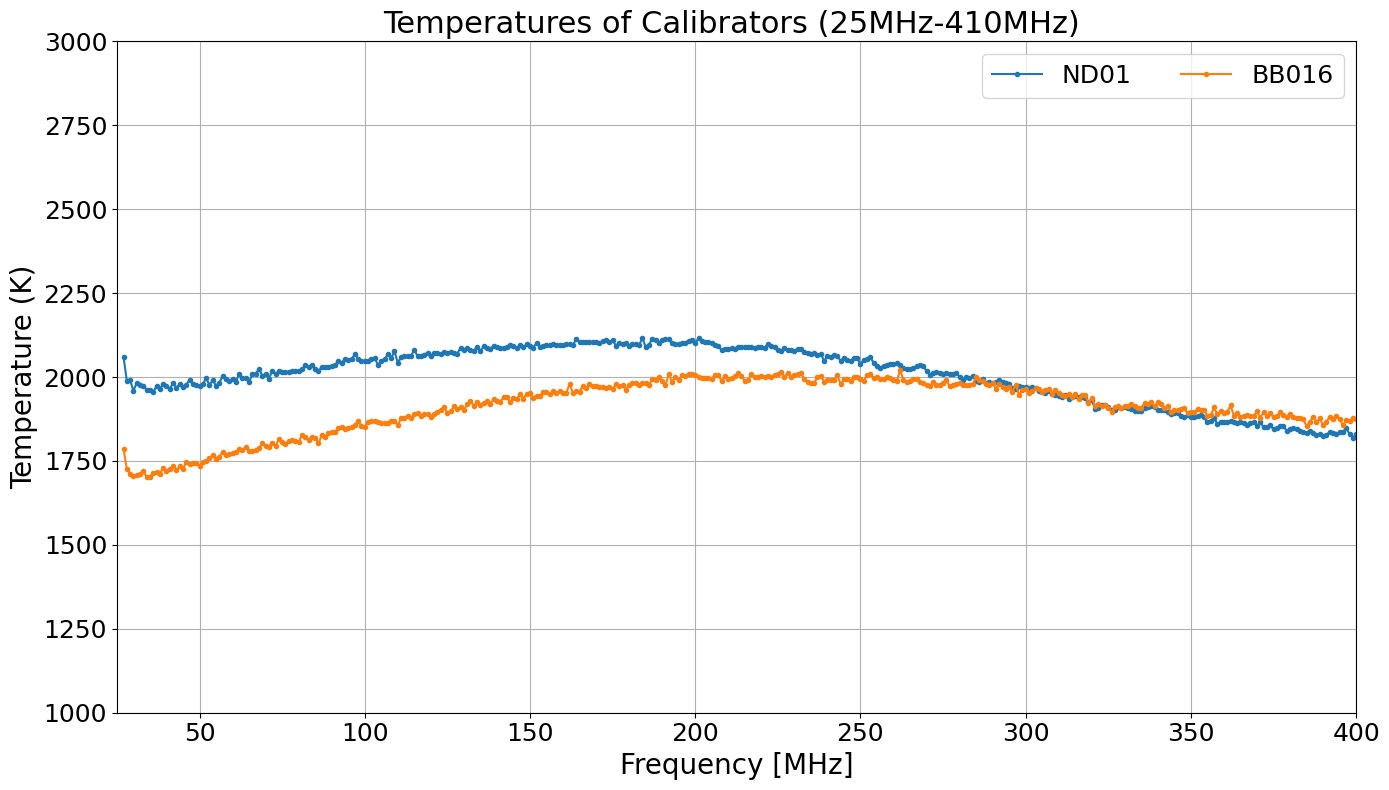

In [62]:
BB013_inferred = BB013_inferred.resample(new_freq=np.arange(20e6, 410e6, 1e6))
BB016_inferred = BB016_inferred.resample(new_freq=np.arange(20e6, 410e6, 1e6))
ND01_inferred = ND01_inferred.resample(new_freq=np.arange(20e6, 410e6, 1e6))

plotter.plot_spectra([ND01_inferred, BB016_inferred], title='Temperatures of Calibrators (25MHz-410MHz) ',
                     ylabel='Temperature (K)', y_range=(1000, 3000),
                     freq_range=(25, 400), marker='o', markersize=3,
                     save_path=pjoin(plot_path, 'Cal_Temperature.png'))

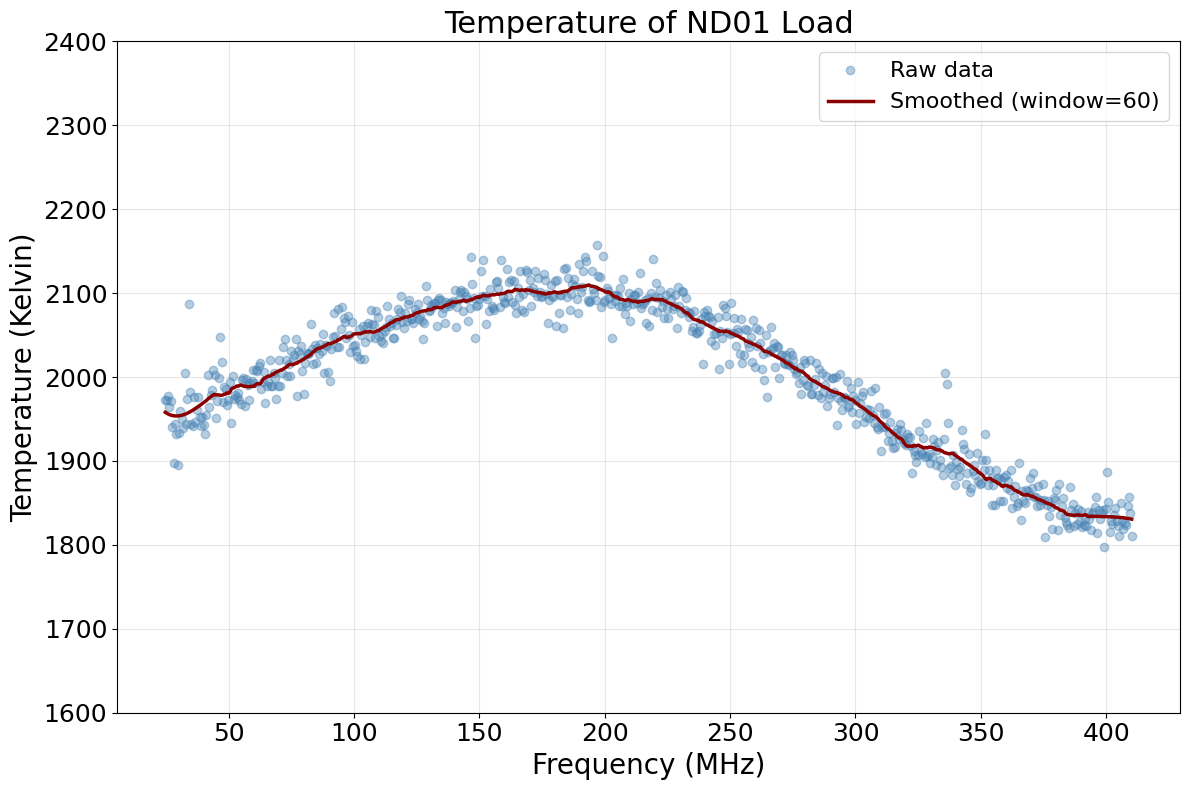

In [88]:
ND01_inferred = LNA_thermo.infer_temperature(
    LNA01_ND01.unit_convert('dBm', 'kelvin', channel_width=1e6, inplace=False), 
    start_freq=25, end_freq=410, ymax=2400, ymin=1600,
    window_size=60,
    title='Temperature of ND01 Load',
    save_path=pjoin(plot_path, 'ND01_Temperature.png'))

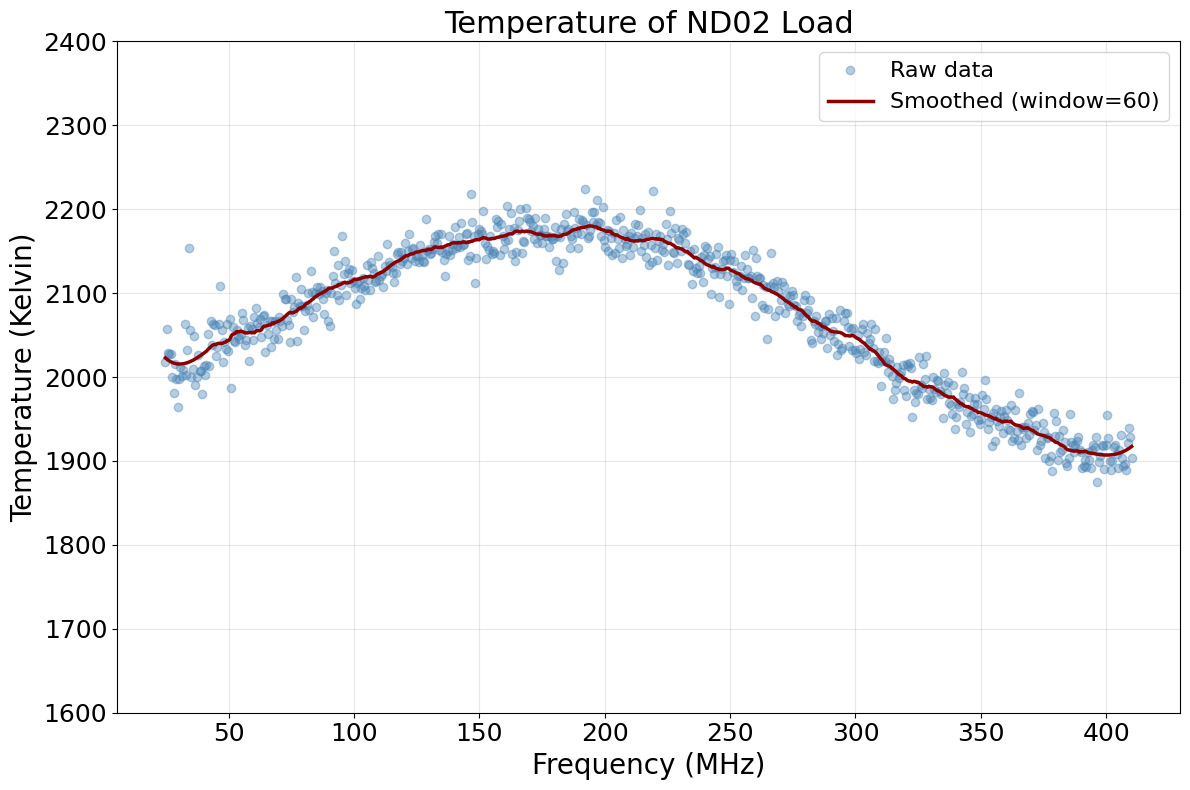

In [89]:
ND02_inferred = LNA_thermo.infer_temperature(
    LNA01_ND02.unit_convert('dBm', 'kelvin', channel_width=1e6, inplace=False), 
    start_freq=25, end_freq=410, ymax=2400, ymin=1600,
    window_size=60,
    title='Temperature of ND02 Load',
    save_path=pjoin(plot_path, 'ND02_Temperature.png'))

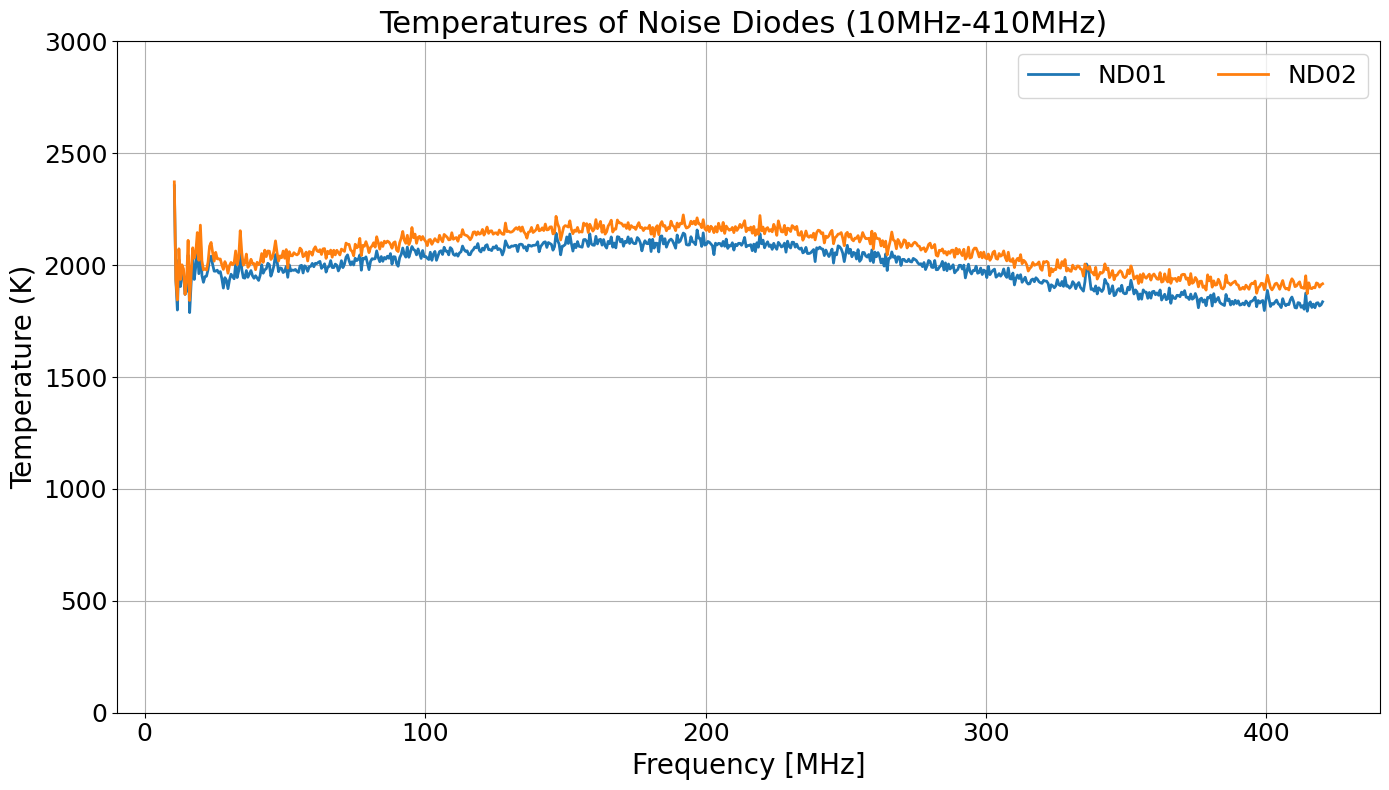

In [90]:
# plot the inferred temperatures of the two noise diodes together for comparison
plotter.plot_spectra([ND01_inferred, ND02_inferred], title='Temperatures of Noise Diodes (10MHz-410MHz) ',
                     ylabel='Temperature (K)', y_range=(0, 3000),
                     save_path=pjoin(plot_path, 'ND01_ND02_Temperature.png'))

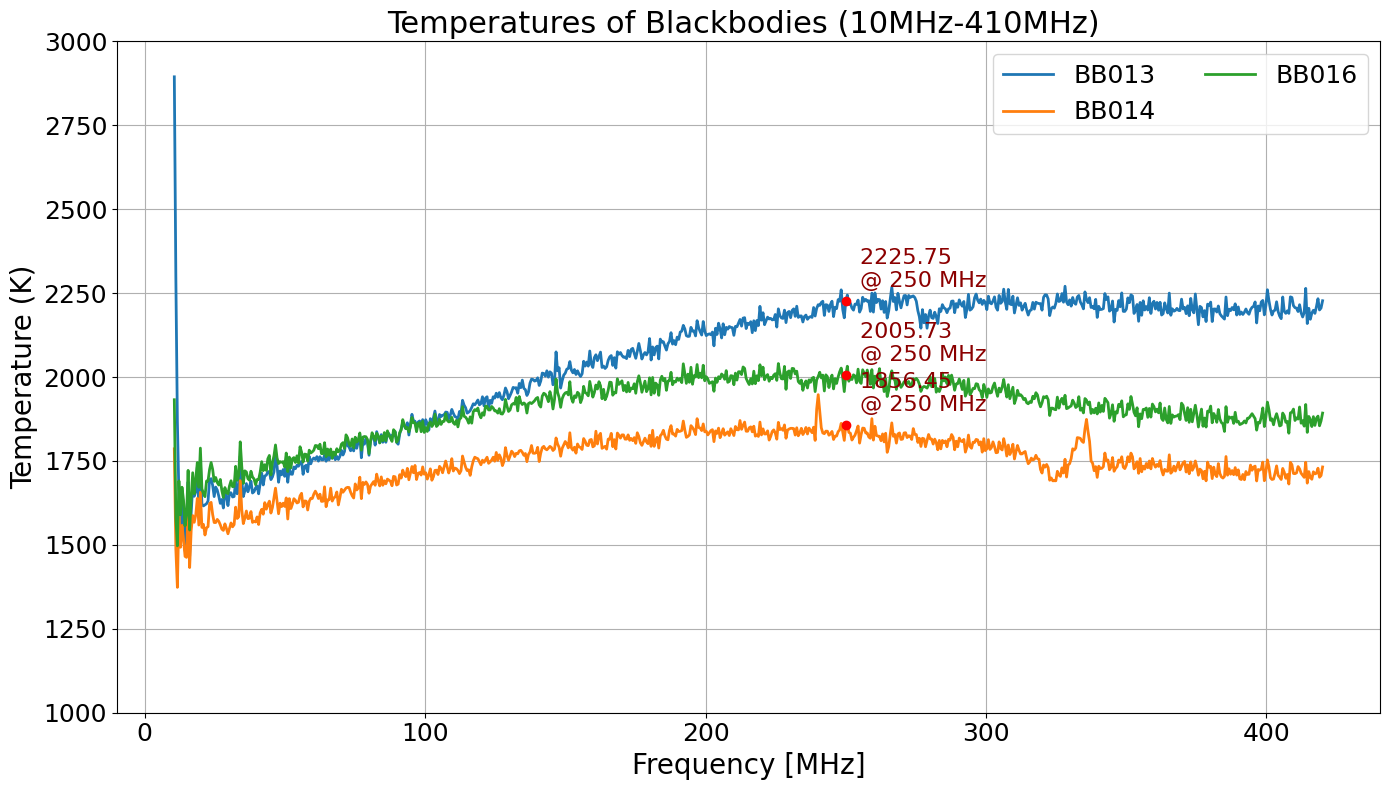

In [97]:
# plot the inferred temperatures of the two noise diodes together for comparison
plotter.plot_spectra([BB013_inferred, BB014_inferred, BB016_inferred], title='Temperatures of Blackbodies (10MHz-410MHz) ',
                     ylabel='Temperature (K)', y_range=(1000, 3000),
                     marker_freqs=[250],
                     save_path=pjoin(plot_path, 'BBs_Temperature.png'))

## Y-Factor Method with second-stage calibration
Since spectrum analyzer brings its own noise figure, we need to calibrate it out to get accurate measurement of the DUT noise temperature. This is done by performing a second-stage calibration with hot and cold loads.

In total, four measurements are needed:
1. hot load connected to 2nd stage amplifier + Spectrum Analyzer (SA)
2. cold load connected to 2nd stage amplifier + SA
3. hot load connected to 1st stage DUT + 2nd stage amplifier + SA
4. cold load connected to 1st stage DUT + 2nd stage amplifier + SA